[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/29_modelisation_covid19.ipynb)



# Modélisation : le projet COVID complet

C'est l'aboutissement. L'EDA (notebook 27) a compris les données, le prétraitement
(notebook 28) les a préparées. Ce notebook construit le modèle final : tester
plusieurs algorithmes, optimiser le meilleur, et l'ajuster pour l'usage médical.

L'enjeu, rappelé par toute l'analyse : détecter les malades du COVID. Vu le
déséquilibre (10 % de positifs) et le contexte médical, l'objectif n'est pas
l'exactitude brute mais le rappel ne rater aucun malade.

## Le plan

| Section | L'étape |
|---|---|
| 1 | Reprise du preprocessing (notebook 28) |
| 2 | Comparer plusieurs modèles |
| 3 | Optimiser par GridSearchCV |
| 4 | Explorer large avec RandomizedSearchCV |
| 5 | La courbe précision-rappel |
| 6 | Ajuster le seuil de décision |

## Deux principes annoncés

On optimise sur le rappel (`scoring='recall'`), pas l'exactitude rater un
malade est la pire erreur.

Et on ajuste le seuil de décision pour attraper plus de vrais positifs, quitte
à accepter des fausses alertes.

Prérequis : les notebooks 27 et 28 (EDA et prétraitement du même projet).

## 1. Reprise du preprocessing

On reprend exactement la chaîne du notebook 28 sélection des colonnes, split,
puis les fonctions de preprocessing.

In [23]:
from google.colab import files
uploaded = files.upload() # dataset.xlsx

Saving dataset.xlsx to dataset (1).xlsx


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_row', 111)
pd.set_option('display.max_columns', 111)

data = pd.read_excel('dataset.xlsx')
df = data.copy()

In [26]:
missing_rate = df.isna().sum() / df.shape[0]

blood_columns = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_columns = list(df.columns[(missing_rate < 0.88) & (missing_rate > 0.75)])
key_columns = ['Patient age quantile', 'SARS-Cov-2 exam result']

df = df[key_columns + blood_columns + viral_columns]

In [27]:
from sklearn.model_selection import train_test_split

trainset, testset = train_test_split(df, test_size=0.2, random_state=0)

In [28]:
def encodage(df):
    code = {'negative': 0, 'positive': 1, 'not_detected': 0, 'detected': 1}
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].map(code)
    return df

def feature_engineering(df):
    df['est malade'] = df[viral_columns].sum(axis=1) >= 1
    df = df.drop(viral_columns, axis=1)
    return df

def imputation(df):
    return df.dropna(axis=0)

def preprocessing(df):
    df = encodage(df)
    df = feature_engineering(df)
    df = imputation(df)
    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']
    print(y.value_counts())
    return X, y

In [29]:
X_train, y_train = preprocessing(trainset)
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    422
1     65
Name: count, dtype: int64
SARS-Cov-2 exam result
0    95
1    16
Name: count, dtype: int64


Tout vient du notebook 28. On sépare avant de nettoyer, on traite train et test
par la même fonction la garantie contre la fuite d'information. On peut maintenant
se concentrer sur les modèles.

## 2. Comparer plusieurs modèles

Plutôt que de parier sur un seul algorithme, on en teste quatre, chacun dans un
pipeline avec le même preprocessing.

In [30]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    N, train_score, val_score = learning_curve(
        model, X_train, y_train,
        cv=4, scoring='f1',
        train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()
    plt.show()

On reprend la fonction `evaluation` du notebook 28 : matrice de confusion,
rapport de classification, et courbe d'apprentissage le tout avec `scoring='f1'`,
adapté au déséquilibre.

### Le preprocessing commun, puis les quatre modèles

In [31]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

preprocessor = make_pipeline(
    PolynomialFeatures(2, include_bias=False),
    SelectKBest(f_classif, k=10))

Le `preprocessor` est un pipeline commun : il crée les interactions polynomiales
(notebook 22), puis garde les 10 meilleures variables (notebook 23). Le
`f_classif` convient aux variables continues, contrairement au `chi2`.

`include_bias=False` évite d'ajouter une colonne de 1 inutile ici.

In [32]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

liste_of_models = {
    'RandomForest': RandomForest,
    'AdaBoost': AdaBoost,
    'SVM': SVM,
    'KNN': KNN,
}

Quatre modèles, quatre familles différentes (notebook 25) :

RandomForest et AdaBoost des ensembles d'arbres, robustes.

SVM et KNN des modèles à distance, d'où le `StandardScaler` en plus dans
leur pipeline. Sans mise à l'échelle, ils seraient dominés par les variables à
grande amplitude (notebook 22).

Les mettre dans un dictionnaire permet de tous les évaluer en une boucle.

RandomForest
[[91  4]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        95
           1       0.60      0.38      0.46        16

    accuracy                           0.87       111
   macro avg       0.75      0.67      0.70       111
weighted avg       0.86      0.87      0.86       111



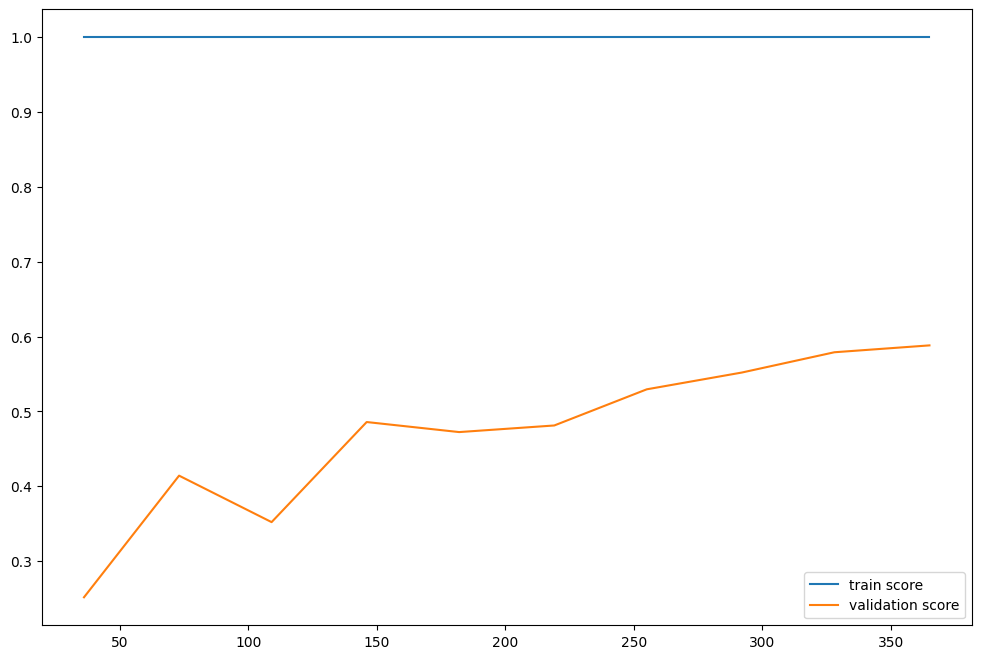

AdaBoost
[[90  5]
 [11  5]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        95
           1       0.50      0.31      0.38        16

    accuracy                           0.86       111
   macro avg       0.70      0.63      0.65       111
weighted avg       0.83      0.86      0.84       111



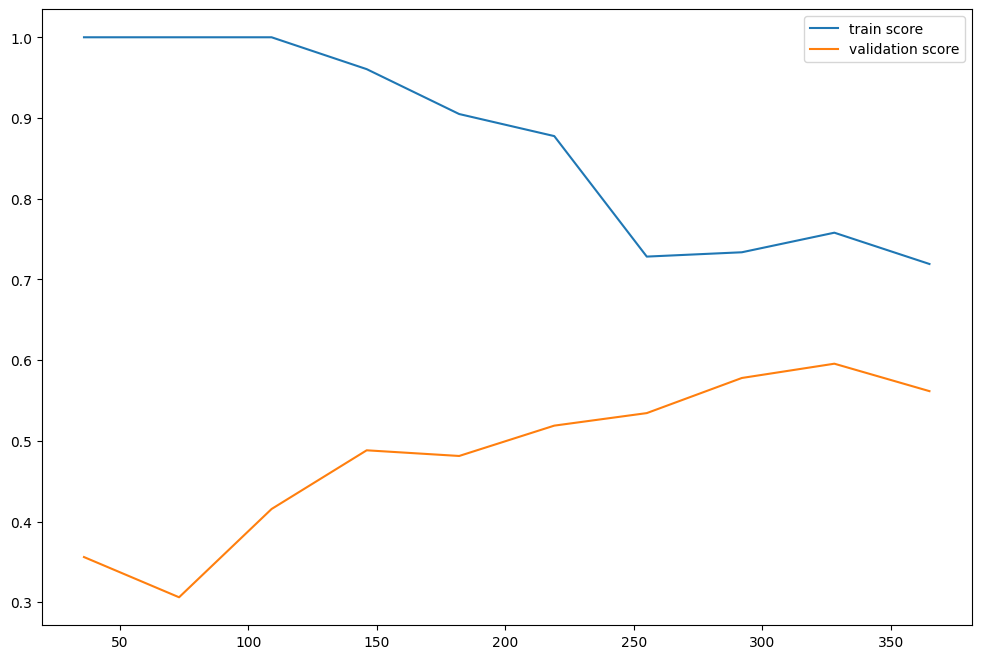

SVM
[[91  4]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        95
           1       0.64      0.44      0.52        16

    accuracy                           0.88       111
   macro avg       0.77      0.70      0.73       111
weighted avg       0.87      0.88      0.87       111



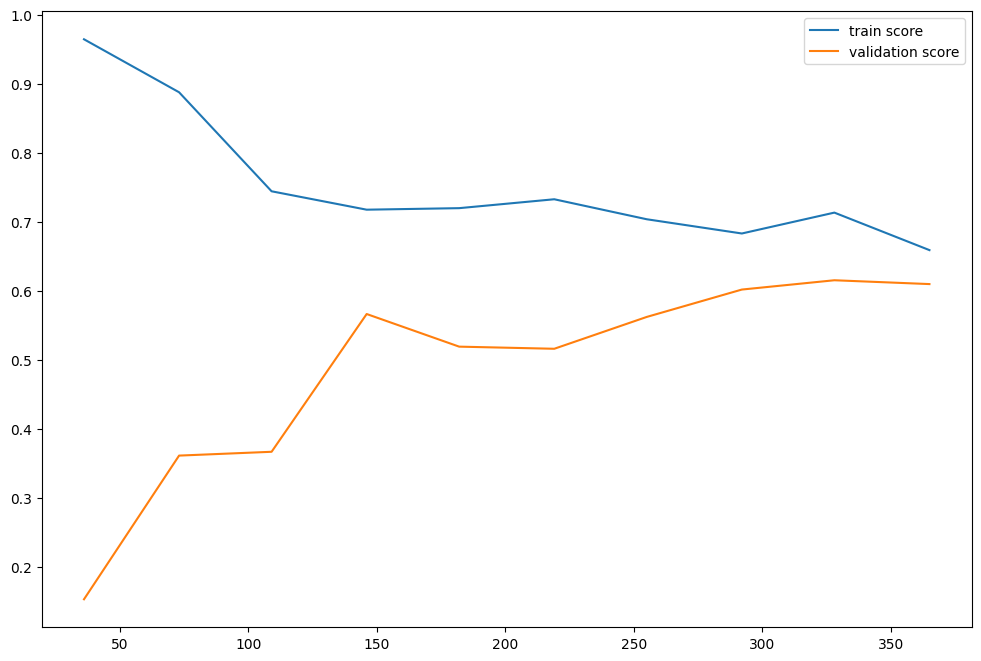

KNN
[[88  7]
 [ 8  8]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        95
           1       0.53      0.50      0.52        16

    accuracy                           0.86       111
   macro avg       0.72      0.71      0.72       111
weighted avg       0.86      0.86      0.86       111



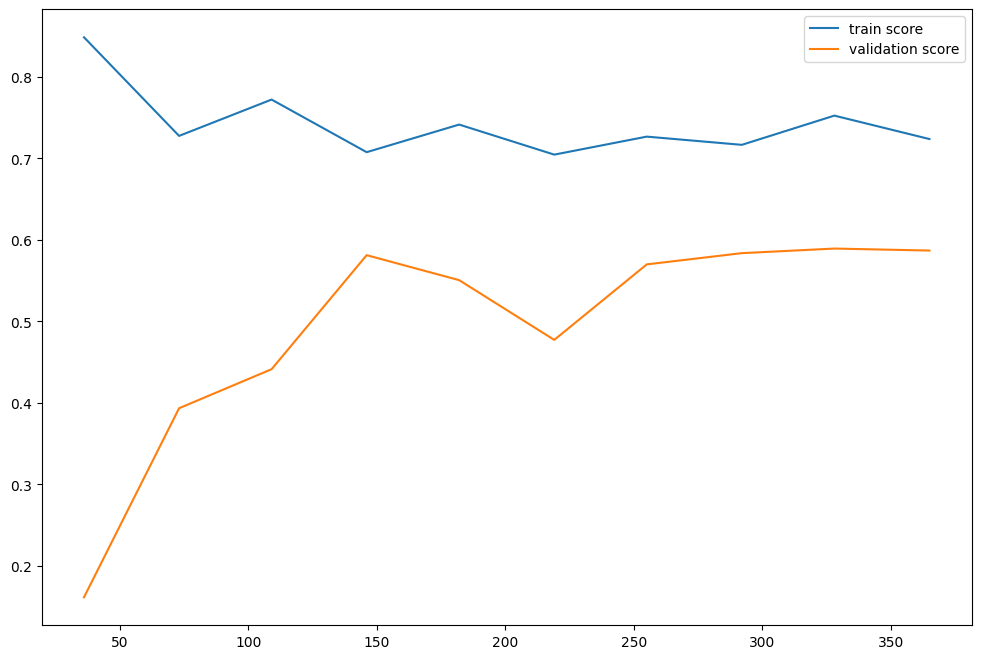

In [33]:
for nom, model in liste_of_models.items():
    print(nom)
    evaluation(model)

On évalue les quatre d'un coup. Chaque sortie donne la matrice de confusion, le
rapport, et la courbe d'apprentissage.

Ce qu'on cherche. Pas le meilleur score brut, mais le meilleur rappel sur
la classe positive celui qui rate le moins de malades. On regarde aussi les
courbes d'apprentissage : lesquels surapprennent (grand écart train/validation),
lesquels bénéficieraient de plus de données.

Souvent, le SVM ressort comme un bon candidat sur ce type de problème c'est celui
qu'on optimise ensuite.

## 3. Optimiser par GridSearchCV

On choisit le SVM et on cherche ses meilleurs hyperparamètres en optimisant le rappel.

In [34]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

hyper_params = {
    'svc__gamma': [1e-3, 1e-4],
    'svc__C': [1, 10, 100, 1000],
}

Le piège des noms exacts. `gamma` prend deux `m` une faute comme `gama`
lève une `ValueError`. Le préfixe `svc__` cible l'étape SVC du pipeline.

Ce que règlent ces deux paramètres :

`C` contrôle la tolérance aux erreurs grand `C`, le modèle colle aux données
(risque de surapprentissage) ; petit `C`, frontière plus souple.

`gamma` contrôle la portée de chaque point grand `gamma`, influence locale ;
petit, influence large. C'est le curseur simplicité/complexité du SVM.

In [35]:
grid = GridSearchCV(SVM, hyper_params, scoring='recall', cv=4)

grid.fit(X_train, y_train)
print('meilleurs paramètres :', grid.best_params_)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

meilleurs paramètres : {'svc__C': 1000, 'svc__gamma': 0.001}
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        95
           1       0.70      0.44      0.54        16

    accuracy                           0.89       111
   macro avg       0.81      0.70      0.74       111
weighted avg       0.88      0.89      0.88       111



Le point crucial : `scoring='recall'`. On n'optimise pas l'exactitude ni même
le f1, mais le rappel la capacité à détecter les vrais positifs.

C'est la traduction de tout ce qu'on a compris : dans ce contexte médical, rater un
COVID (faux négatif) est bien plus grave qu'une fausse alerte. GridSearch cherche
donc les paramètres qui attrapent le plus de malades, même au prix de quelques
fausses alertes.

[[92  3]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        95
           1       0.70      0.44      0.54        16

    accuracy                           0.89       111
   macro avg       0.81      0.70      0.74       111
weighted avg       0.88      0.89      0.88       111



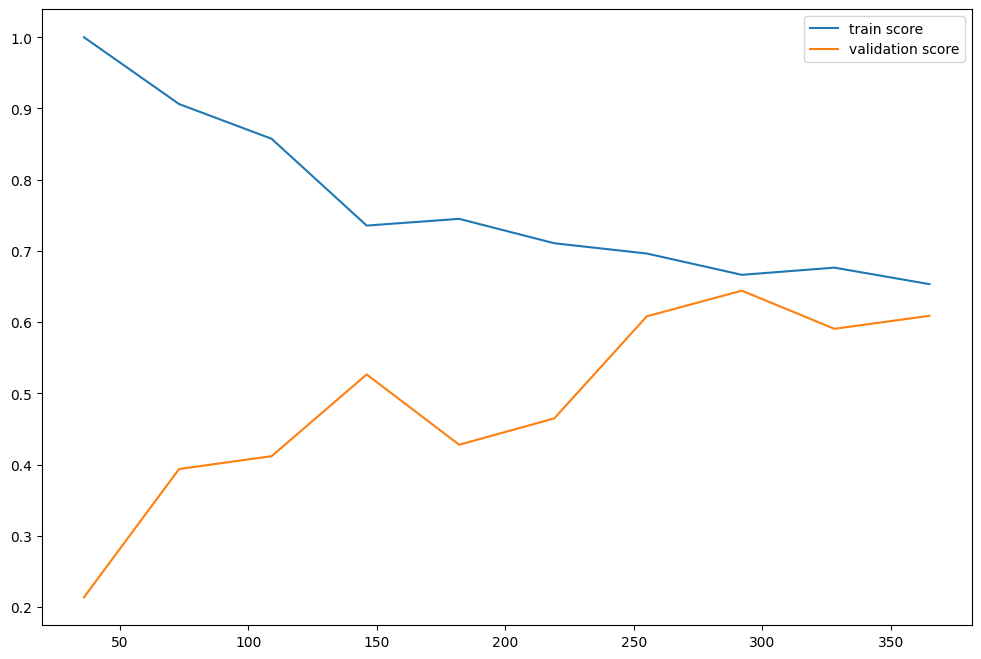

In [36]:
evaluation(grid.best_estimator_)

On évalue le meilleur modèle trouvé. Le `best_estimator_` est le SVM réentraîné
avec les meilleurs paramètres prêt à l'emploi.

## 4. Explorer plus large : RandomizedSearchCV

GridSearch teste toutes les combinaisons vite trop lourd si on ajoute des
paramètres. `RandomizedSearchCV` en teste un échantillon au hasard, ce qui
permet d'explorer un espace bien plus grand.

In [37]:
hyper_params = {
    'svc__gamma': [1e-3, 1e-4],
    'svc__C': [1, 10, 100, 1000],
    'pipeline__polynomialfeatures__degree': [2, 3, 4],
    'pipeline__selectkbest__k': range(4, 100),
}

La syntaxe imbriquée. Ici on règle des paramètres d'un pipeline dans un
pipeline. Le chemin descend par étages :

`pipeline__polynomialfeatures__degree` = dans l'étape `pipeline` (le preprocessor),
l'étape `polynomialfeatures`, le paramètre `degree`.

Chaque `__` descend d'un niveau le prolongement de la syntaxe du notebook 22, sur
plusieurs étages. On règle ainsi le degré polynomial et le nombre de variables
sélectionnées, en même temps que les paramètres du SVM.

Avec ces quatre paramètres, GridSearch testerait des milliers de combinaisons.
RandomizedSearch en tire un échantillon.

In [38]:
grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4, n_iter=40)

grid.fit(X_train, y_train)
print('meilleurs paramètres :', grid.best_params_)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

meilleurs paramètres : {'svc__gamma': 0.001, 'svc__C': 1000, 'pipeline__selectkbest__k': 65, 'pipeline__polynomialfeatures__degree': 3}
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        95
           1       0.50      0.50      0.50        16

    accuracy                           0.86       111
   macro avg       0.71      0.71      0.71       111
weighted avg       0.86      0.86      0.86       111



`n_iter=40` teste 40 combinaisons au hasard parmi toutes les possibles. C'est le
compromis de RandomizedSearch : on ne garantit pas de trouver l'optimum absolu,
mais on explore largement pour un coût maîtrisé.

### Affiner autour du meilleur

Une fois une bonne zone trouvée, on resserre la recherche autour d'elle.

In [39]:
hyper_params = {
    'svc__gamma': [1e-3, 1e-4],
    'svc__C': [1, 10, 100, 1000],
    'pipeline__polynomialfeatures__degree': [2, 3, 4],
    'pipeline__selectkbest__k': range(10, 30), # fourchette resserrée
}

grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4, n_iter=40)
grid.fit(X_train, y_train)
print('meilleurs paramètres :', grid.best_params_)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

meilleurs paramètres : {'svc__gamma': 0.001, 'svc__C': 1000, 'pipeline__selectkbest__k': 18, 'pipeline__polynomialfeatures__degree': 3}
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        95
           1       0.50      0.31      0.38        16

    accuracy                           0.86       111
   macro avg       0.70      0.63      0.65       111
weighted avg       0.83      0.86      0.84       111



On a resserré `k` de la plage 4-100 à 10-30, autour de la valeur qui marchait. C'est
la démarche classique : explorer large d'abord, affiner ensuite. On concentre les
40 essais sur la zone prometteuse plutôt que de les disperser.

## 5. La courbe précision-rappel

On a optimisé le rappel. Mais il y a un compromis entre rappel et précision, et
on peut le régler finement grâce au seuil de décision.

In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, seuils = precision_recall_curve(
    y_test,
    grid.best_estimator_.decision_function(X_test))

`decision_function` donne le score brut du SVM pour chaque patient pas
juste 0 ou 1, mais une valeur continue. Plus le score est haut, plus le modèle est
confiant que c'est un positif.

`precision_recall_curve` calcule, pour chaque seuil possible sur ce score, la
précision et le rappel correspondants. C'est ce compromis qu'on va visualiser.

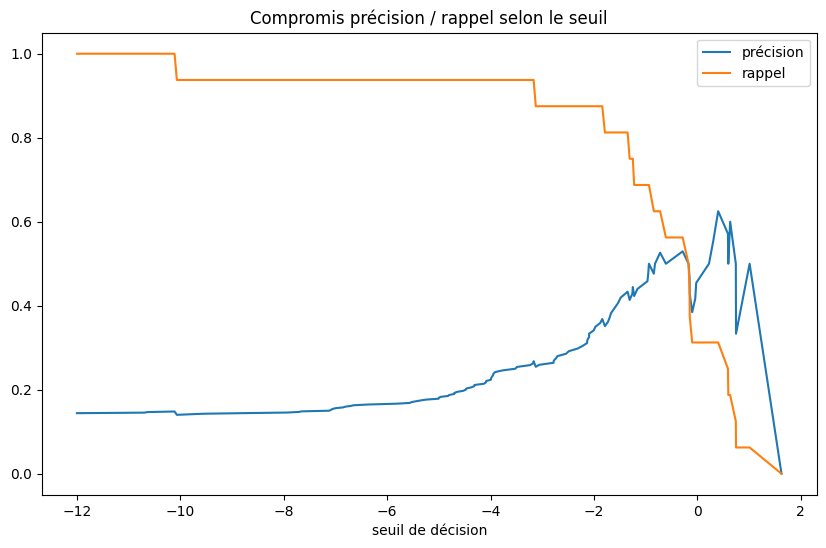

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(seuils, precision[:-1], label='précision')
plt.plot(seuils, recall[:-1], label='rappel')
plt.xlabel('seuil de décision')
plt.legend()
plt.title('Compromis précision / rappel selon le seuil')
plt.show()

Note : `precision[:-1]` on retire le dernier point, car
`precision_recall_curve` renvoie un point de plus pour les précisions/rappels que
pour les seuils. Sans ce `[:-1]`, les tableaux n'auraient pas la même longueur et
le tracé échouerait.

Comment lire cette courbe. Les deux quantités évoluent en sens inverse :

Quand on baisse le seuil, on déclare positifs plus de patients on attrape
plus de vrais malades (rappel mont), mais aussi plus de fausses alertes
(précision baisse).

Quand on monte le seuil, on est plus exigeant moins de fausses alertes
(précision monte), mais on rate plus de malades (rappel baisse).

Le point où les deux courbes se croisent est l'équilibre. Mais pour notre problème
médical, on ne veut pas l'équilibre on veut privilégier le rappel.

## 6. Ajuster le seuil de décision

Par défaut, un modèle prédit « positif » si son score dépasse 0. On peut changer ce
seuil pour attraper plus de malades.

In [42]:
def model_final(model, X, seuil=0):
    return model.decision_function(X) > seuil

Cette fonction reproduit la décision du modèle, mais avec un seuil réglable. Au
lieu du 0 par défaut, on peut le baisser pour être plus « inclusif ».

In [43]:
# Seuil abaissé à -1 : on attrape plus de positifs
y_pred = model_final(grid.best_estimator_, X_test, seuil=-1)

from sklearn.metrics import f1_score, recall_score
print('f1 :', round(f1_score(y_test, y_pred), 3))
print('rappel :', round(recall_score(y_test, y_pred), 3))

f1 : 0.55
rappel : 0.688


Ce qu'on fait ici est le geste final, celui qui adapte le modèle à l'usage réel.

En baissant le seuil de 0 à -1, on demande au modèle d'être moins exigeant pour
déclarer un positif. Résultat : le rappel augmente on détecte plus de vrais
malades. La contrepartie est plus de fausses alertes, mais on l'a assumé : dans un
contexte médical, mieux vaut sur-diagnostiquer et confirmer que rater un malade.

C'est l'aboutissement de tout le raisonnement du projet. On a :

1. Compris les données (EDA, notebook 27).
2. Préparé sans fuite (prétraitement, notebook 28).
3. Comparé plusieurs modèles.
4. Optimisé le meilleur sur le rappel.
5. Ajusté le seuil pour maximiser la détection des malades.

Le modèle final n'est pas « le plus précis » au sens naïf c'est celui qui rate
le moins de COVID, ce qui est exactement l'objectif médical.

### Choisir le seuil sur la courbe

On peut lire sur la courbe précision-rappel le seuil qui donne le rappel voulu.
Par exemple, pour un rappel d'au moins 90 % :

In [44]:
# Le seuil qui garantit un rappel >= 0.9
import numpy as np

idx = np.argmax(recall[:-1] < 0.9) # premier point sous 0.9 en descendant
seuil_choisi = seuils[idx]
print('pour un rappel élevé, seuil autour de :', round(seuil_choisi, 3))

y_pred = model_final(grid.best_estimator_, X_test, seuil=seuil_choisi)
print('rappel obtenu :', round(recall_score(y_test, y_pred), 3))

pour un rappel élevé, seuil autour de : -3.124
rappel obtenu : 0.875


On choisit le seuil en fonction de l'objectif métier ici, un rappel élevé
pour la sécurité des patients. C'est une décision qui ne se lit pas dans un score
automatique : elle dépend de ce que coûte chaque type d'erreur dans le monde réel.

C'est peut-être la leçon la plus importante du cours : le machine learning ne
s'arrête pas au `fit`. Le bon modèle est celui qui répond au vrai problème, et
cela demande de comprendre le contexte, pas seulement d'optimiser un chiffre.

## 7. Mémo : la modélisation complète

### La démarche

1. Reprendre le preprocessing (fonctions du notebook 28).
2. Comparer plusieurs modèles dans des pipelines.
3. Optimiser le meilleur par GridSearchCV ou RandomizedSearchCV.
4. Choisir le bon scoring (`recall` ici, selon l'objectif).
5. Tracer la courbe précision-rappel.
6. Ajuster le seuil de décision selon le contexte.

### Les outils

```python
# comparer des modèles
for nom, model in liste_of_models.items():
    evaluation(model)

# optimiser
GridSearchCV(model, params, scoring='recall', cv=4)
RandomizedSearchCV(model, params, scoring='recall', cv=4, n_iter=40)

# seuil
model.decision_function(X) > seuil
precision_recall_curve(y_test, model.decision_function(X_test))
```

### La syntaxe imbriquée

```python
'svc__gamma' # paramètre du SVC
'pipeline__polynomialfeatures__degree' # pipeline dans pipeline
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `gama` au lieu de `gamma` | `ValueError` |
| `scoring='accuracy'` sur déséquilibré | optimise la mauvaise chose |
| Oublier `precision[:-1]` | tableaux de tailles différentes |
| Seuil par défaut en médecine | rate trop de malades |
| GridSearch sur trop de params | explosion combinatoire, préférer Randomized |

## 8. Exercices

**Exercice 1**

Compare les quatre modèles (RandomForest, AdaBoost, SVM, KNN) sur leur rappel
de la classe positive. Lequel détecte le mieux les malades avant optimisation ?
Est-ce le même que celui qui a la meilleure accuracy ?

**Exercice 2**

Trace la courbe précision-rappel du modèle optimisé, et détermine le seuil qui
donne un rappel de 0,9. Quelle précision obtient-on à ce seuil ? Combien de fausses
alertes cela représente-t-il, et est-ce acceptable en contexte médical ?

**Exercice 3**

Un responsable veut « le modèle le plus précis possible » et propose de monter le
seuil de décision pour réduire les fausses alertes. Explique pourquoi, dans le
cadre du dépistage COVID, c'est exactement la mauvaise stratégie en t'appuyant
sur le coût comparé d'un faux négatif et d'un faux positif.

## Félicitations

Tu viens de terminer un projet de machine learning complet, de bout en bout,
sur des données médicales réelles :

- Exploration (27) : comprendre des données brutes et trouées.
- Prétraitement (28) : nettoyer, encoder, préparer sans fuite.
- Modélisation (29) : comparer, optimiser, ajuster au vrai problème.

C'est exactement le travail d'un data scientist. Les techniques apprises tout au
long du cours NumPy, Pandas, visualisation, sklearn, pipelines, validation,
ensembles se sont toutes réunies dans ce projet final.

La compétence la plus rare que tu as développée n'est pas technique : c'est de
garder en tête le vrai objectif (ne pas rater de malades) et d'y plier chaque
choix, du scoring au seuil. Un modèle n'est bon que s'il répond à la bonne
question.